# Import Libraries

In [1]:
import re
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import itertools
from itertools import combinations
from tqdm import tqdm
import csv
import mlxtend
from mlxtend.frequent_patterns import apriori, association_rules

warnings.filterwarnings("ignore")
pd.set_option('display.max_colwidth', None)

# Single-Column Profiling

In [6]:
def run_single_column_profiling(csv_path):
    print("\n" + "="*50)
    print("TASK: SINGLE-COLUMN PROFILING")
    print("="*50)

    # 1. LOAD DATA
    print("------ 1. LOAD DATA ------")
    df = pd.read_csv(csv_path, encoding="utf-8", dtype=str)
    df.columns = [c.strip() for c in df.columns]
    for col in df.columns:
        df[col] = df[col].str.strip()
    RAW_COLUMNS = list(df.columns)
    num_rows = len(df)
    print(df.shape)

    # 2. DERIVE COLUMNS
    print("\n\n\n------ 2. DERIVE COLUMNS ------")
    df["inspection_date_parsed"] = pd.to_datetime(df["Inspection Date"], errors="coerce")

    def count_violations(val):
        if pd.isna(val) or str(val).strip() == "":
            return 0
        return len([s for s in str(val).split("|") if s.strip()])

    df["No. of Violations"] = df["Violations"].apply(count_violations).astype(int)

    for col in ["Inspection ID", "License #", "Latitude", "Longitude"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # 3. HELPER FUNCTIONS
    print("\n\n\n------ 3. HELPER FUNCTIONS ------")
    def safe_str_lengths(series):
        return series.dropna().astype(str).str.len()

    def infer_type(col, series):
        if col == "Inspection Date":
            return "datetime"
        numeric_series = pd.to_numeric(series.dropna(), errors="coerce")
        if numeric_series.notna().sum() / max(series.notna().sum(), 1) >= 0.8:
            return "numeric"
        return "text"

    def first_nonzero_digit(val):
        try:
            s = str(int(abs(float(val))))
            for ch in s:
                if ch != "0":
                    return int(ch)
        except Exception:
            pass
        return None

    def iqr_outliers(series):
        q1, q3 = series.quantile(0.25), series.quantile(0.75)
        iqr = q3 - q1
        lb, ub = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        return lb, ub

    # 4. CARDINALITY PROFILE
    print("\n\n\n------ 4. CARDINALITY PROFILE ------")
    profile_rows = []

    for col in RAW_COLUMNS:
        series = df[col]
        null_count = series.isna().sum()
        distinct = series.nunique(dropna=True)
        inferred = infer_type(col, series)

        str_min = str_max = str_med = str_mean = np.nan
        if inferred in ("text", "datetime"):
            lens = safe_str_lengths(series)
            if len(lens):
                str_min, str_max = lens.min(), lens.max()
                str_med, str_mean = lens.median(), lens.mean()

        vc = series.value_counts(dropna=False)
        constancy = vc.iloc[0] / num_rows if len(vc) else np.nan

        profile_rows.append({
            "column": col, "num_rows": num_rows,
            "null_count": null_count, "null_pct": round(null_count / num_rows * 100, 2),
            "distinct": distinct, "uniqueness": round(distinct / num_rows, 4),
            "str_len_min": str_min, "str_len_max": str_max,
            "str_len_median": str_med,
            "str_len_mean": round(str_mean, 2) if not np.isnan(str_mean) else np.nan,
            "constancy": round(constancy, 4), "inferred_type": inferred,
        })

    cardinality_profile = pd.DataFrame(profile_rows)
    display(cardinality_profile)

    # 5. NUMERIC DISTRIBUTIONS
    print("\n\n\n------ 5. NUMERIC DISTRIBUTIONS ------")
    numeric_stats = []
    NUMERIC_COLS = ["Inspection ID", "License #", "Latitude", "Longitude", "No. of Violations"]
    for col in NUMERIC_COLS:
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        if s.empty:
            continue
        numeric_stats.append({
            "column": col,
            "min": s.min(), "max": s.max(),
            "mean": round(s.mean(), 4), "median": s.median(),
            "variance": round(s.var(), 4),
            "Q1": s.quantile(0.25), "Q2": s.quantile(0.50), "Q3": s.quantile(0.75),
        })
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(s, bins=30, color="steelblue", edgecolor="white")
        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        plt.tight_layout()
        plt.show()

    display(pd.DataFrame(numeric_stats))

    # 6. CATEGORICAL VALUE COUNTS (TOP 20)
    print("\n\n\n------ 6. CATEGORICAL VALUE COUNTS (TOP 20) ------")
    CATEGORICAL_COLS = ["Facility Type", "Risk", "City", "State", "Inspection Type", "Results"]
    BAR_PLOT_COLS = ["Facility Type", "Risk", "Inspection Type", "Results", "City"]

    for col in CATEGORICAL_COLS:
        vc = df[col].value_counts(dropna=False).head(20)
        vc_norm = df[col].value_counts(normalize=True, dropna=False).head(20).round(4)
        display(pd.DataFrame({"count": vc, "freq": vc_norm}))

        if col in BAR_PLOT_COLS:
            fig, ax = plt.subplots(figsize=(10, 5))
            vc.plot(kind="bar", ax=ax, color="teal", edgecolor="white")
            ax.set_title(col)
            ax.set_ylabel("Count")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()

    # 7. VIOLATION CODE FREQUENCY
    print("\n\n\n------ 7. VIOLATION CODE FREQUENCY ------")
    viol_codes = (
        df["Violations"].dropna()
        .str.split("|", expand=False)
        .explode()
        .str.strip()
        .str.extract(r"^(\d+)\.")
        [0]
        .dropna()
        .astype(int)
    )

    viol_freq = viol_codes.value_counts().sort_index()
    viol_freq.name = "count"
    display(viol_freq.to_frame())

    fig, ax = plt.subplots(figsize=(14, 5))
    viol_freq.plot(kind="bar", ax=ax, color="teal", edgecolor="white")
    ax.set_title("Violation Code Frequency")
    ax.set_xlabel("Violation Code")
    ax.set_ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # 8. TYPE & PATTERN ANALYSIS
    print("\n\n\n------ 8. TYPE & PATTERN ANALYSIS ------")
    # Zip
    zip_str = df["Zip"].fillna("").astype(str).str.strip()
    zip_lengths = zip_str.str.len()
    display(zip_lengths.value_counts().sort_index())
    print(f"5-char: {(zip_lengths == 5).mean():.4f}  |  "
          f"digits-only: {zip_str.str.fullmatch(r'\d+').fillna(False).mean():.4f}")

    # State
    state_vals = df["State"].dropna().unique()
    frac_il = (df["State"].str.upper().str.strip() == "IL").mean()
    print(f"States: {sorted(state_vals)}  |  IL fraction: {frac_il:.4f}")

    # City
    display(df["City"].value_counts(dropna=False).head(10))
    city_upper = df["City"].str.upper()
    print(f"CHICAGO exact: {(df['City'] == 'CHICAGO').sum()}  |  "
          f"Chicago title: {(df['City'] == 'Chicago').sum()}  |  "
          f"any variant: {city_upper.str.strip().eq('CHICAGO').sum()}")

    # Location
    loc_pattern = re.compile(r"^\s*\(\s*-?\d+\.?\d*\s*,\s*-?\d+\.?\d*\s*\)\s*$")
    loc_valid = df["Location"].dropna().apply(lambda x: bool(loc_pattern.match(x)))
    print(f"Location pattern match: {loc_valid.sum() / len(df):.4f}")

    # 9. VALIDITY PROFILE
    print("\n\n\n------ 9. VALIDITY PROFILE ------")
    def validity_row(check_name, valid_mask):
        v = valid_mask.sum()
        inv = (~valid_mask).sum()
        return {"check": check_name, "valid": v, "valid_pct": round(v / num_rows * 100, 2),
                "invalid": inv, "invalid_pct": round(inv / num_rows * 100, 2)}


    validity_profile = pd.DataFrame([
        validity_row("Inspection Date parseable", df["inspection_date_parsed"].notna()),
        validity_row("Zip 5 digits",
                    df["Zip"].fillna("").astype(str).str.strip().str.fullmatch(r"\d{5}").fillna(False)),
        validity_row("State == IL", df["State"].str.upper().str.strip().eq("IL").fillna(False)),
        validity_row("Lat in [41.5, 42.2]",
                    pd.to_numeric(df["Latitude"], errors="coerce").pipe(
                        lambda s: s.notna() & s.between(41.5, 42.2))),
        validity_row("Lon in [-88, -87]",
                    pd.to_numeric(df["Longitude"], errors="coerce").pipe(
                        lambda s: s.notna() & s.between(-88.0, -87.0))),
    ])
    display(validity_profile)

    # 10. OUTLIER DETECTION (IQR) -- COORDINATES
    print("\n\n\n------ 10. OUTLIER DETECTION (IQR) -- COORDINATES ------")
    outlier_summary = []
    for col in ["Latitude", "Longitude"]:
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        if s.empty:
            continue
        lb, ub = iqr_outliers(s)
        n_out = pd.to_numeric(df[col], errors="coerce").apply(
            lambda x: pd.notna(x) and (x < lb or x > ub)).sum()
        outlier_summary.append({"column": col, "lower": round(lb, 4), "upper": round(ub, 4),
                                "outliers": n_out, "pct": round(n_out / num_rows * 100, 2)})

    outlier_df = pd.DataFrame(outlier_summary)
    display(outlier_df)

    # 11. Rare categories (< 1%)
    print("\n\n\n------ 11. Rare categories (< 1%) ------")
    for col in ["Facility Type", "Inspection Type", "Results"]:
        vc = df[col].value_counts(normalize=True)
        rare = vc[vc < 0.01]
        if not rare.empty:
            display(rare)

    # 12. BENFORD'S LAW -- LICENSE # AND INSPECTION ID
    print("\n\n\n------ 12. BENFORD'S LAW -- LICENSE # AND INSPECTION ID ------")
    benford_ref = {d: np.log10(1 + 1 / d) for d in range(1, 10)}

    for col in ["License #", "Inspection ID"]:
        series = pd.to_numeric(df[col], errors="coerce").dropna()
        if series.empty:
            continue

        digits = series.apply(first_nonzero_digit).dropna().astype(int)
        digit_counts = digits.value_counts().reindex(range(1, 10), fill_value=0).sort_index()
        digit_freq = digit_counts / digit_counts.sum()

        display(pd.DataFrame({
            "digit": range(1, 10), "count": digit_counts.values,
            "frequency": digit_freq.values.round(4),
            "benford_expected": [round(benford_ref[d], 4) for d in range(1, 10)],
        }))

        fig, ax = plt.subplots(figsize=(7, 4))
        x = np.arange(1, 10)
        ax.bar(x - 0.2, digit_freq.values, width=0.4, label="Empirical", color="steelblue")
        ax.bar(x + 0.2, [benford_ref[d] for d in range(1, 10)], width=0.4,
              label="Benford", color="salmon", alpha=0.8)
        ax.set_xticks(x)
        ax.set_title(col)
        ax.set_xlabel("First Digit")
        ax.set_ylabel("Frequency")
        ax.legend()
        plt.tight_layout()
        plt.show()

    return df

# Association Rule Mining

In [18]:
def run_association_rule_mining(csv_path, columns_to_analyze=None, min_support=0.05):
    print("\n" + "="*50)
    print("TASK: ASSOCIATION RULE MINING")
    print("="*50)

    if columns_to_analyze is None:
        columns_to_analyze = ['Facility Type', 'Risk', 'Inspection Type', 'Results']

    # 1. LOAD DATA
    print(f"------ 1. LOAD DATA ------")
    df = pd.read_csv(csv_path, encoding="utf-8", dtype=str)
    df.columns = [c.strip() for c in df.columns]

    # 2. SELECTION & CLEANING
    print(f"\n\n\n------ 2. SELECTING RELEVANT CATEGORICAL COLUMNS ------")
    # Drop rows with empty values in columns of interest
    df_subset = df[columns_to_analyze].dropna()

    # 3. ONE-HOT ENCODING
    print("\n\n\n------ 3. ONE-HOT ENCODING THE DATA ------")
    # Convert categorical variables into dummy/indicator variables (True/False format)
    # Adding prefixes helps us know which column the value came from in the final rules,
    # eg: Results_Out of Business ('Out of Business' is a value of 'Results' column)
    df_encoded = pd.get_dummies(df_subset, prefix=columns_to_analyze)

    # mlxtend requires the dataframe to be strictly boolean type
    df_encoded = df_encoded.astype('bool')

    # 4. FREQUENT ITEMSETS (Apriori Algorithm)
    # min_support=0.05 means a combination must appear in at least 5% of all inspections.
    print(f"\n\n\n------ 4. RUNNING APRIORI ALGORITHM (min_support={min_support}) ------")
    frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)

    if frequent_itemsets.empty:
        print("Warning: No frequent itemsets found. Try lowering min_support.")
        return None

    # 5. GENERATE ASSOCIATION RULES
    print(f"\n\n\n------ 5. GENERATE ASSOCIATION RULES ------")
    # We use 'lift' as the metric. A lift > 1 means the items are positively correlated.
    # min_threshold=1.2 ensures we only get rules showing a reasonably strong correlation.

    # Lift: The strength of the correlation. A lift of 1 means they are independent.
    # A lift of 2.0 means X and Y appear together twice as often as you would expect by random chance.

    # could use support and / or confidence minimum thesholds too
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

    rules = rules.sort_values(by='lift', ascending=False).reset_index(drop=True)

    # 6. DISPLAY TOP RESULTS
    if rules is not None:
        # antecedents = LHS, consequents = RHS
        display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
        print(f"\nSuccessfully generated {len(rules)} rules.")
        print("\n------ Top 10 Association Rules ------")
        display(rules[display_cols].head(10))
    else:
        print("No association rules met the threshold.")

    return rules

# Functional Dependencies

In [19]:
def run_functional_dependencies(csv_path):
    print("\n" + "="*50)
    print("TASK: FUNCTIONAL DEPENDENCIES")
    print("="*50)

    # 1. LOAD AND PREPARE DATA
    print(f"------ 1. LOAD DATA ------")
    df = pd.read_csv(csv_path, encoding="utf-8", dtype=str)
    df.columns = [c.strip() for c in df.columns]

    # Drop free-text and derived/duplicate columns
    DROP_COLS = ["Violations", "Location"]
    df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

    # Drop rows with nulls (nulls create false FD violations)
    df = df.dropna()

    print(f"  Full dataset : {len(df):,} rows, {len(df.columns)} columns")
    print(f"  Columns      : {list(df.columns)}\n")

    cols = list(df.columns)

    # 2. FIND FDs
    print(f"\n\n\n------ 2. FIND FDs ------")

    # Sample for discovery, keep full df for verification
    SAMPLE_SIZE = 150_000
    df_sample = df.sample(min(SAMPLE_SIZE, len(df)), random_state=42)
    print(f"  Sample size  : {len(df_sample):,} rows\n")

    # Precompute unique counts per column (used for pruning)
    unique_counts = {col: df_sample[col].nunique() for col in cols}
    print("Unique value counts per column:")
    for col, n in sorted(unique_counts.items(), key=lambda x: -x[1]):
        print(f"  {col:40s}: {n:,}")
    print()

    # Core FD check
    def holds(df, lhs: list, rhs: str) -> bool:
        # Returns True if LHS → RHS holds (each LHS group maps to exactly 1 RHS value)
        return (df.groupby(lhs)[rhs].nunique() <= 1).all()

    # Composite unique count for pruning multi-col LHS
    def lhs_unique(df, lhs: list) -> int:
        # Number of unique combinations in a composite LHS
        return df.groupby(lhs).ngroups

    # Find all minimal non-trivial FDs
    def find_minimal_nontrivial_fds(df, cols, max_lhs_size=3):
        """
        Finds all minimal, non-trivial FDs using three pruning strategies:

        Pruning 1 — Trivial check    : skip if rhs is already in lhs
        Pruning 2 — Unique count     : skip if nunique(lhs) < nunique(rhs)
                                      (impossible for FD to hold)
        Pruning 3 — Minimality       : skip if any proper subset of lhs
                                      already determines rhs (not minimal)
        """
        minimal_fds = []

        # Stores (frozenset(lhs), rhs) for all FDs found so far
        # Used for minimality pruning in larger LHS sizes
        known_fds = set()

        # outer loop : LHS size from 1 to max
        for lhs_size in range(1, max_lhs_size + 1):
            print(f"Checking LHS size {lhs_size}...")
            total_checked = 0
            pruned_trivial = 0
            pruned_count   = 0
            pruned_minimal = 0
            found          = 0

            # inner loop 1: take LHS
            for lhs in combinations(cols, lhs_size):
                lhs_set    = frozenset(lhs)
                lhs_n_uniq = lhs_unique(df, list(lhs))

                # inner loop 2: take RHS
                for rhs in cols:

                    # Pruning 1: Trivial (RHS already in LHS)
                    if rhs in lhs_set:
                        pruned_trivial += 1
                        continue

                    # Pruning 2: Unique count
                    # If LHS has fewer unique combos than RHS unique values,
                    # it's impossible for LHS → RHS to hold
                    if lhs_n_uniq < unique_counts[rhs]:
                        pruned_count += 1
                        continue

                    # Pruning 3: Minimality
                    # If any proper subset of LHS already determines RHS,
                    # this FD is not minimal - skip
                    is_minimal = True
                    for subset_size in range(1, lhs_size):
                        # take subset and check if already exists valid FDs
                        for subset in combinations(lhs, subset_size):
                            # if subset is already in known FDs = not minimal -> skip
                            if (frozenset(subset), rhs) in known_fds:
                                is_minimal = False
                                break
                        if not is_minimal:
                            break

                    if not is_minimal:
                        pruned_minimal += 1
                        continue

                    # Expensive check only if all pruning passed
                    total_checked += 1
                    if holds(df, list(lhs), rhs):
                        minimal_fds.append({
                            "lhs":      list(lhs),
                            "rhs":      rhs,
                            "lhs_size": lhs_size
                        })
                        known_fds.add((lhs_set, rhs))
                        found += 1

            print(f"  Pruned - trivial: {pruned_trivial:,} | "
                  f"Pruned - unique count: {pruned_count:,} | "
                  f"Pruned- minimality: {pruned_minimal:,}")
            print(f"  FD candidates passed pruning and checked with sample dataset: {total_checked:,} | Valid FDs Found: {found}\n")

        return pd.DataFrame(minimal_fds)

    fds_sample = find_minimal_nontrivial_fds(df_sample, cols, max_lhs_size=3)

    # Verify on full dataset
    print(f"Verifying {len(fds_sample)} FDs on full dataset ({len(df):,} rows)...")

    verified_rows = []
    for _, row in fds_sample.iterrows():
        # check if FD also holds in full dataset
        full_holds = holds(df, row["lhs"], row["rhs"])
        # append if verified
        verified_rows.append({**row, "holds_on_full": full_holds})

    verified_df = pd.DataFrame(verified_rows)

    # Print figures
    sample_only = (~verified_df["holds_on_full"]).sum() # FDs that hold only on sample
    confirmed   = verified_df["holds_on_full"].sum() # FDs that hold on full dataset

    print(f"  Confirmed on full data : {confirmed}")
    print(f"  Sample only (rejected) : {sample_only}\n")

    # Final results
    strict = verified_df[verified_df["holds_on_full"] == True].copy()

    print("=" * 60)
    print(f"ALL MINIMAL NON-TRIVIAL FDs ({len(strict)} total)")
    print("=" * 60)

    for size in range(1, 4):
        group = strict[strict["lhs_size"] == size]
        if len(group) == 0:
            continue
        print(f"\n── LHS size {size} ({len(group)} FDs) ──")
        for _, row in group.iterrows():
            print(f"  {row['lhs']}  →  '{row['rhs']}'")

    # Save
    strict[["lhs", "rhs", "lhs_size"]].to_csv("minimal_FDs.csv", index=False)
    print("\nSaved to: minimal_FDs.csv")

    return strict[["lhs", "rhs", "lhs_size"]]

# Functional Dependencies (No Sampling)

In [27]:
def run_functional_dependencies_no_sampling(csv_path):
    print("\n" + "="*50)
    print("TASK: FUNCTIONAL DEPENDENCIES (NO SAMPLING)")
    print("="*50)

    # 1. LOAD AND PREPARE DATA
    print(f"------ 1. LOAD DATA ------")
    df = pd.read_csv(csv_path, encoding="utf-8", dtype=str)
    df.columns = [c.strip() for c in df.columns]

    # Drop free-text and derived/duplicate columns
    DROP_COLS = ["Violations", "Location"]
    df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

    # Drop rows with nulls (nulls create false FD violations)
    df = df.dropna()

    print(f"  Full dataset : {len(df):,} rows, {len(df.columns)} columns")
    print(f"  Columns      : {list(df.columns)}\n")

    cols = list(df.columns)

    # 2. FIND FDs
    print(f"\n\n\n------ 2. FIND FDs ------")

    df_sample = df

    # Precompute unique counts per column (used for pruning)
    unique_counts = {col: df_sample[col].nunique() for col in cols}
    print("Unique value counts per column:")
    for col, n in sorted(unique_counts.items(), key=lambda x: -x[1]):
        print(f"  {col:40s}: {n:,}")
    print()

    # Core FD check
    def holds(df, lhs: list, rhs: str) -> bool:
        # Returns True if LHS → RHS holds (each LHS group maps to exactly 1 RHS value)
        return (df.groupby(lhs)[rhs].nunique() <= 1).all()

    # Composite unique count for pruning multi-col LHS
    def lhs_unique(df, lhs: list) -> int:
        # Number of unique combinations in a composite LHS
        return df.groupby(lhs).ngroups

    # Find all minimal non-trivial FDs
    def find_minimal_nontrivial_fds(df, cols, max_lhs_size=3):
        """
        Finds all minimal, non-trivial FDs using three pruning strategies:

        Pruning 1 — Trivial check    : skip if rhs is already in lhs
        Pruning 2 — Unique count     : skip if nunique(lhs) < nunique(rhs)
                                      (impossible for FD to hold)
        Pruning 3 — Minimality       : skip if any proper subset of lhs
                                      already determines rhs (not minimal)
        """
        minimal_fds = []

        # Stores (frozenset(lhs), rhs) for all FDs found so far
        # Used for minimality pruning in larger LHS sizes
        known_fds = set()

        # outer loop : LHS size from 1 to max
        for lhs_size in range(1, max_lhs_size + 1):
            print(f"Checking LHS size {lhs_size}...")
            total_checked = 0
            pruned_trivial = 0
            pruned_count   = 0
            pruned_minimal = 0
            found          = 0

            # inner loop 1: take LHS
            for lhs in combinations(cols, lhs_size):
                lhs_set    = frozenset(lhs)
                lhs_n_uniq = lhs_unique(df, list(lhs))

                # inner loop 2: take RHS
                for rhs in cols:

                    # Pruning 1: Trivial (RHS already in LHS)
                    if rhs in lhs_set:
                        pruned_trivial += 1
                        continue

                    # Pruning 2: Unique count
                    # If LHS has fewer unique combos than RHS unique values,
                    # it's impossible for LHS → RHS to hold
                    if lhs_n_uniq < unique_counts[rhs]:
                        pruned_count += 1
                        continue

                    # Pruning 3: Minimality
                    # If any proper subset of LHS already determines RHS,
                    # this FD is not minimal - skip
                    is_minimal = True
                    for subset_size in range(1, lhs_size):
                        # take subset and check if already exists valid FDs
                        for subset in combinations(lhs, subset_size):
                            # if subset is already in known FDs = not minimal -> skip
                            if (frozenset(subset), rhs) in known_fds:
                                is_minimal = False
                                break
                        if not is_minimal:
                            break

                    if not is_minimal:
                        pruned_minimal += 1
                        continue

                    # Expensive check only if all pruning passed
                    total_checked += 1
                    if holds(df, list(lhs), rhs):
                        minimal_fds.append({
                            "lhs":      list(lhs),
                            "rhs":      rhs,
                            "lhs_size": lhs_size
                        })
                        known_fds.add((lhs_set, rhs))
                        found += 1

            print(f"  Pruned - trivial: {pruned_trivial:,} | "
                  f"Pruned - unique count: {pruned_count:,} | "
                  f"Pruned- minimality: {pruned_minimal:,}")
            print(f"  FD candidates passed pruning and checked with sample dataset: {total_checked:,} | Valid FDs Found: {found}\n")

        return pd.DataFrame(minimal_fds)

    fds_sample = find_minimal_nontrivial_fds(df_sample, cols, max_lhs_size=3)

    verified_df = fds_sample

    # Final results
    strict = verified_df.copy()

    print("=" * 60)
    print(f"ALL MINIMAL NON-TRIVIAL FDs ({len(strict)} total)")
    print("=" * 60)

    for size in range(1, 4):
        group = strict[strict["lhs_size"] == size]
        if len(group) == 0:
            continue
        print(f"\n── LHS size {size} ({len(group)} FDs) ──")
        for _, row in group.iterrows():
            print(f"  {row['lhs']}  →  '{row['rhs']}'")

    # Save
    strict[["lhs", "rhs", "lhs_size"]].to_csv("minimal_FDs_no_sampling.csv", index=False)
    print("\nSaved to: minimal_FDs_no_sampling.csv")

    return strict[["lhs", "rhs", "lhs_size"]]

# Perform Tasks


TASK: SINGLE-COLUMN PROFILING
------ 1. LOAD DATA ------
(267531, 17)



------ 2. DERIVE COLUMNS ------



------ 3. HELPER FUNCTIONS ------



------ 4. CARDINALITY PROFILE ------


,column,num_rows,null_count,null_pct,distinct,uniqueness,str_len_min,str_len_max,str_len_median,str_len_mean,constancy,inferred_type
0,Inspection ID,267531,0,0.00,267531,1.0000,NaN,NaN,NaN,NaN,0.0000,numeric
1,DBA Name,267531,0,0.00,32165,0.1202,1.0,79.0,18.0,18.73,0.0133,text
2,AKA Name,267531,2473,0.92,30614,0.1144,2.0,79.0,17.0,17.91,0.0163,text
3,License #,267531,18,0.01,44503,0.1663,NaN,NaN,NaN,NaN,0.0026,numeric
4,Facility Type,267531,5115,1.91,513,0.0019,3.0,47.0,10.0,11.11,0.6721,text
5,Risk,267531,81,0.03,4,0.0000,3.0,15.0,13.0,13.29,0.7328,text
6,Address,267531,0,0.00,19639,0.0734,0.0,51.0,17.0,17.61,0.0122,text
7,City,267531,161,0.06,78,0.0003,5.0,20.0,7.0,7.00,0.9960,text
8,State,267531,59,0.02,5,0.0000,2.0,2.0,2.0,2.00,0.9997,text
9,Zip,267531,49,0.02,121,0.0005,NaN,NaN,NaN,NaN,0.0368,numeric





------ 5. NUMERIC DISTRIBUTIONS ------


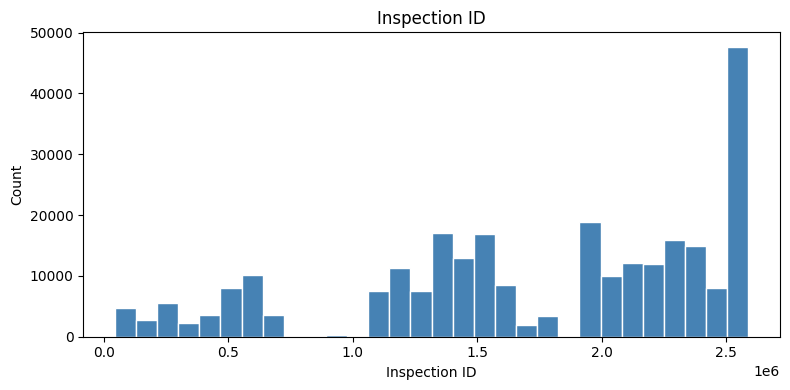

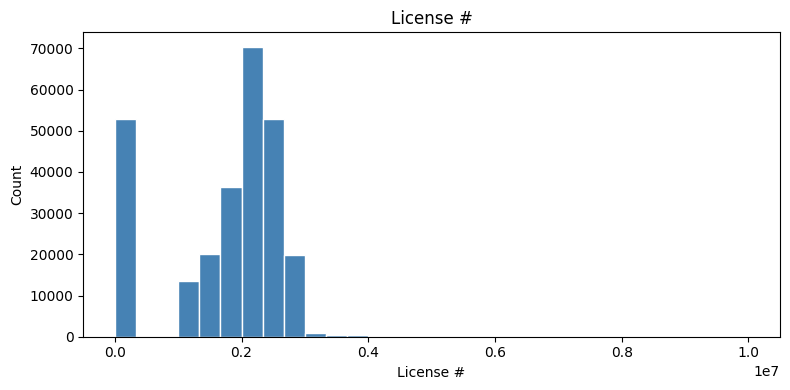

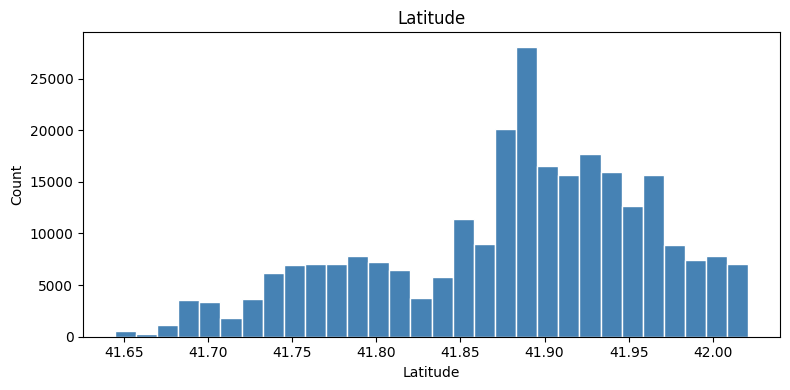

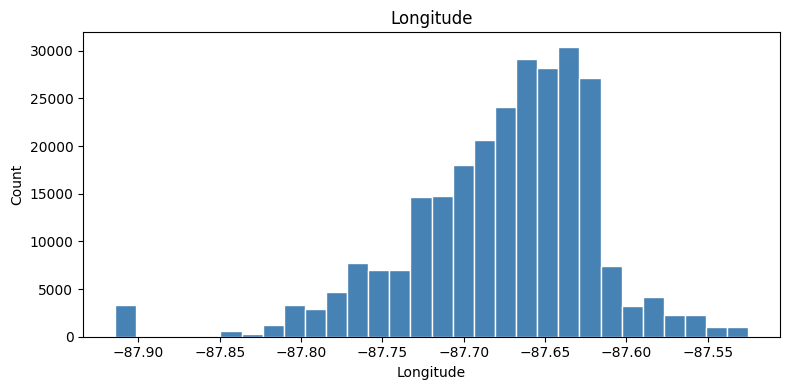

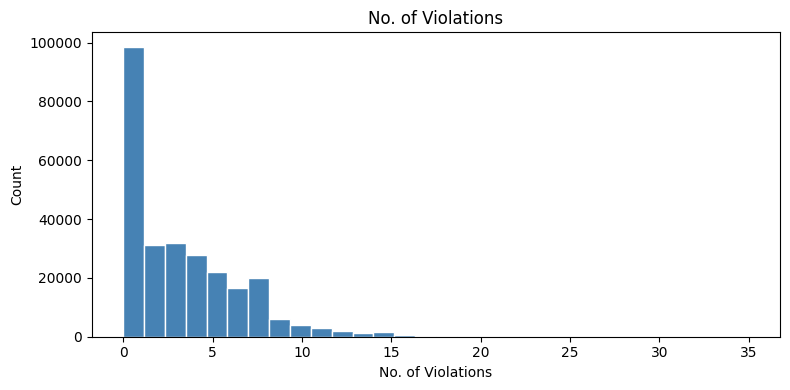

,column,min,max,mean,median,variance,Q1,Q2,Q3
0,Inspection ID,44247.000000,2.589430e+06,1.729715e+06,1.950830e+06,5.175845e+11,1.307352e+06,1.950830e+06,2.356946e+06
1,License #,0.000000,9.999999e+06,1.721737e+06,2.048784e+06,8.591924e+11,1.336815e+06,2.048784e+06,2.369039e+06
2,Latitude,41.644670,4.202106e+01,4.188070e+01,4.189177e+01,6.600000e-03,4.183182e+01,4.189177e+01,4.193979e+01
3,Longitude,-87.914428,-8.752509e+01,-8.767640e+01,-8.766642e+01,3.400000e-03,-8.770746e+01,-8.766642e+01,-8.763494e+01
4,No. of Violations,0.000000,3.500000e+01,3.282900e+00,3.000000e+00,1.132900e+01,0.000000e+00,3.000000e+00,5.000000e+00





------ 6. CATEGORICAL VALUE COUNTS (TOP 20) ------


,count,freq
Facility Type,,
Restaurant,179811,0.6721
Grocery Store,33299,0.1245
School,16882,0.0631
Children's Services Facility,5714,0.0214
NaN,5115,0.0191
Bakery,3848,0.0144
Daycare Above and Under 2 Years,3559,0.0133
Daycare (2 - 6 Years),3128,0.0117
Long Term Care,1961,0.0073


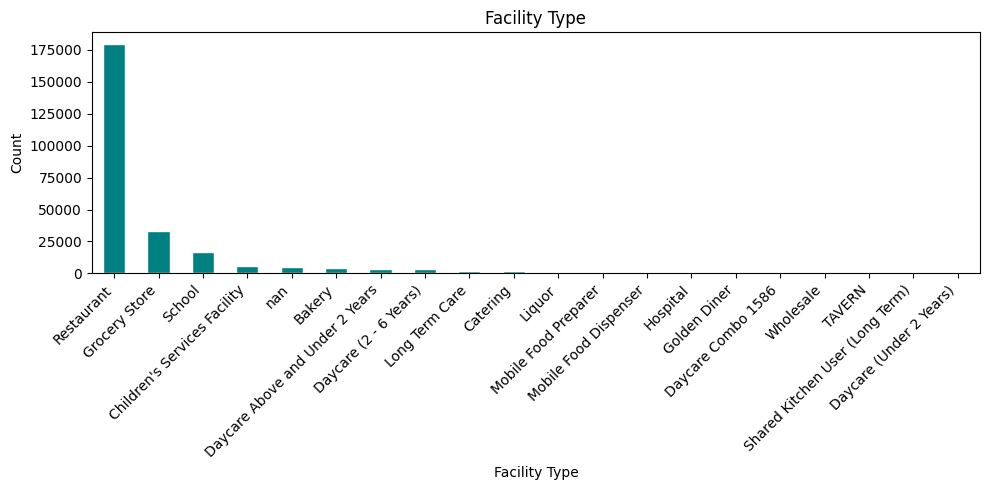

,count,freq
Risk,,
Risk 1 (High),196048,0.7328
Risk 2 (Medium),49560,0.1852
Risk 3 (Low),21790,0.0814
NaN,81,0.0003
All,52,0.0002


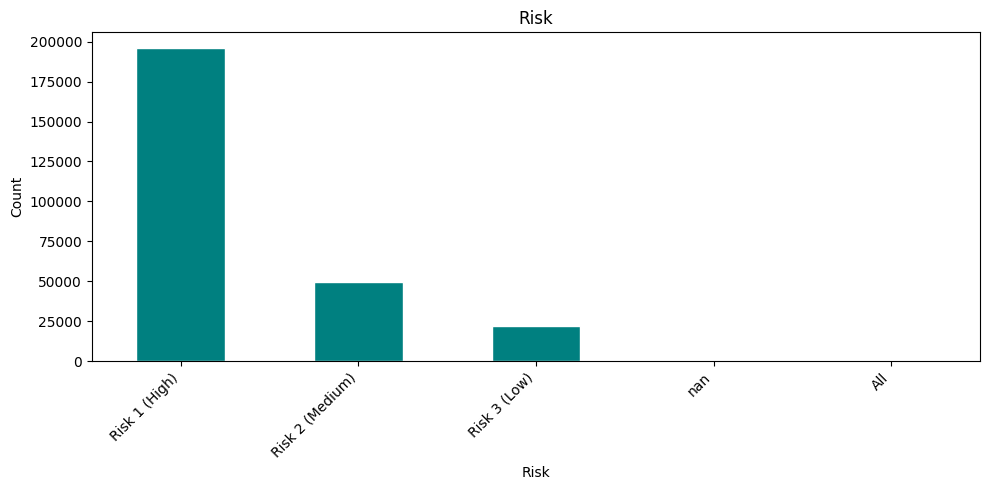

,count,freq
City,,
CHICAGO,266472,0.9960
Chicago,415,0.0016
NaN,161,0.0006
chicago,140,0.0005
CCHICAGO,55,0.0002
SCHAUMBURG,28,0.0001
CHicago,20,0.0001
EVANSTON,18,0.0001
MAYWOOD,15,0.0001


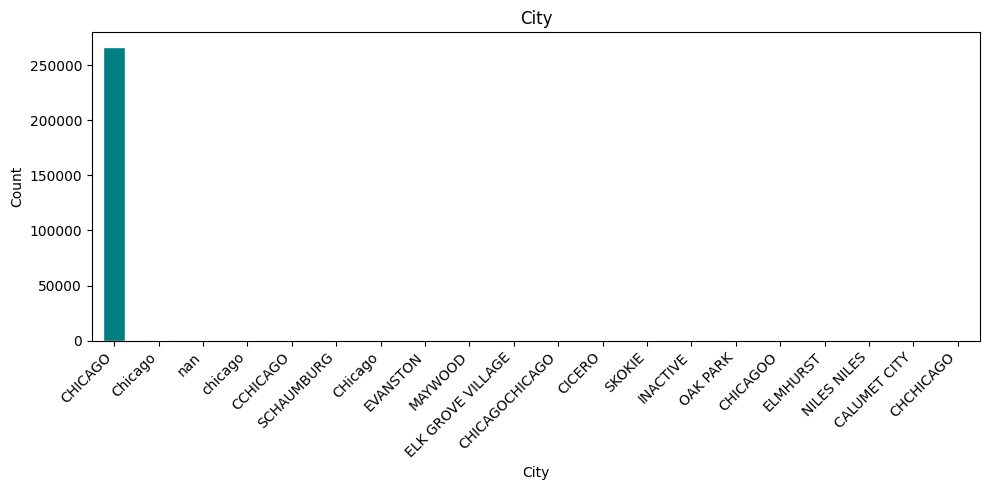

,count,freq
State,,
IL,267461,0.9997
NaN,59,0.0002
IN,7,0.0000
CA,2,0.0000
WI,1,0.0000
NY,1,0.0000


,count,freq
Inspection Type,,
Canvass,139061,0.5198
License,35707,0.1335
Canvass Re-Inspection,29456,0.1101
Complaint,25349,0.0948
License Re-Inspection,11458,0.0428
Complaint Re-Inspection,10615,0.0397
Short Form Complaint,8311,0.0311
Non-Inspection,2823,0.0106
Suspected Food Poisoning,971,0.0036


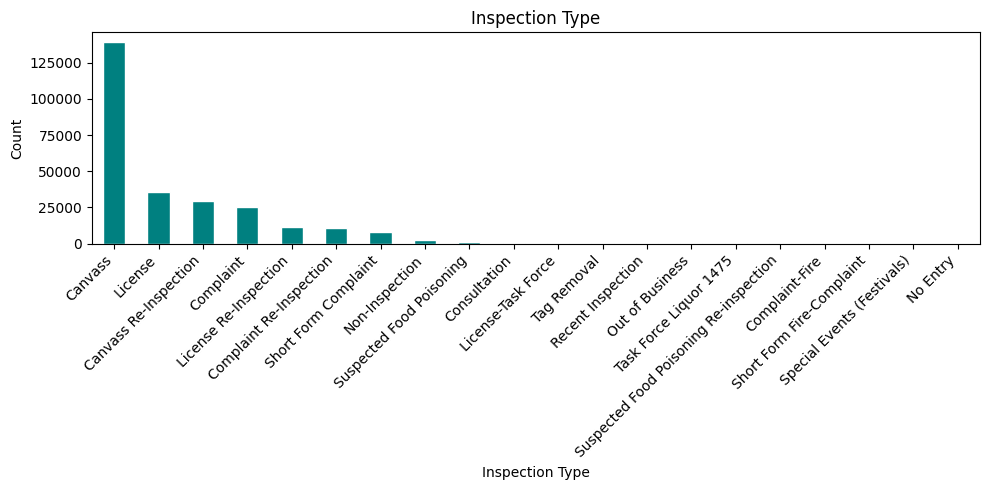

,count,freq
Results,,
Pass,137733,0.5148
Fail,52265,0.1954
Pass w/ Conditions,40750,0.1523
Out of Business,22616,0.0845
No Entry,10689,0.0400
Not Ready,3392,0.0127
Business Not Located,86,0.0003


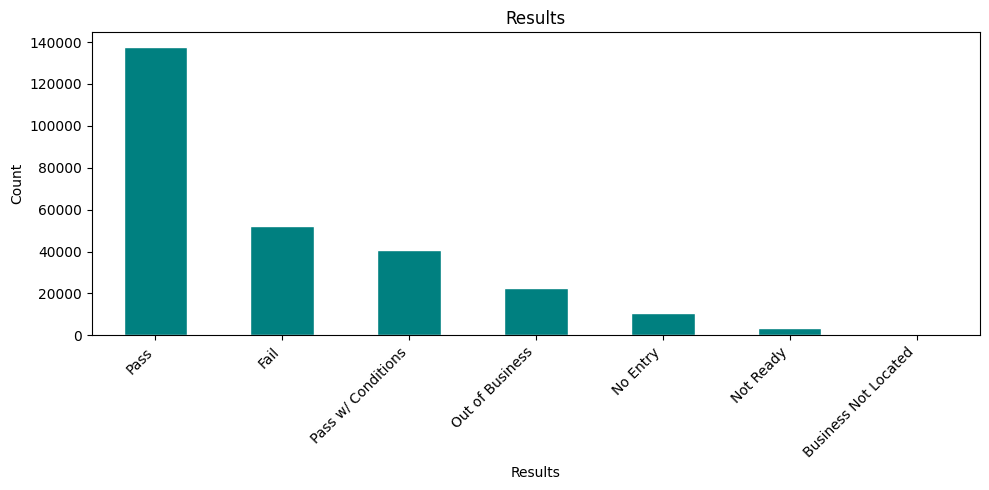




------ 7. VIOLATION CODE FREQUENCY ------


,count
0,
1,4094
2,13572
3,26060
4,530
5,18144
...,...
61,1397
62,141
63,35


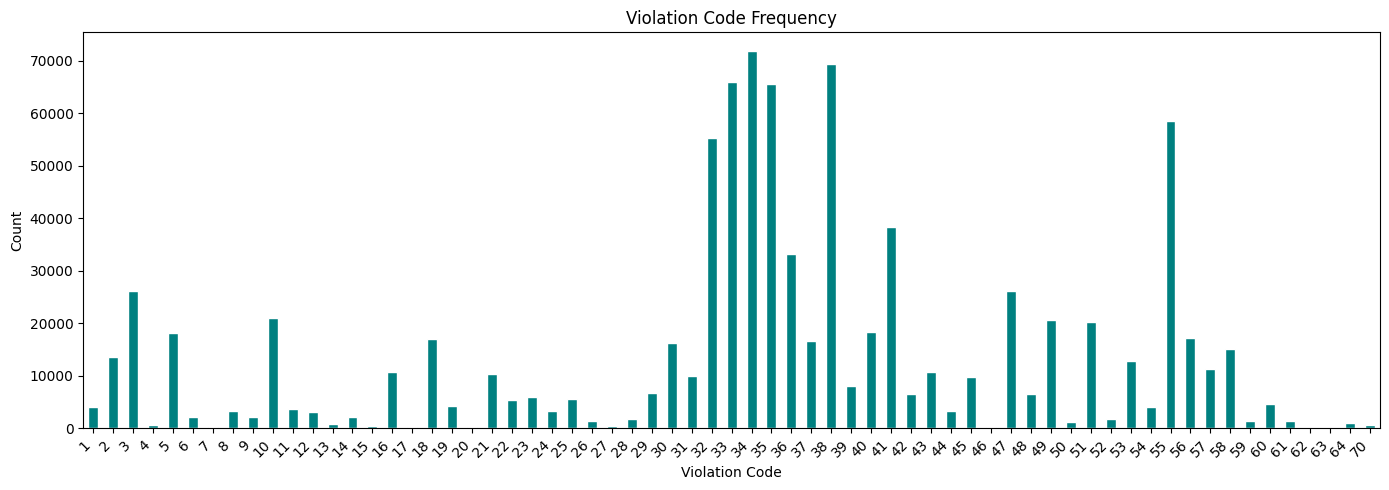




------ 8. TYPE & PATTERN ANALYSIS ------


,count
Zip,
0,49
5,267482


5-char: 0.9998  |  digits-only: 0.9998
States: ['CA', 'IL', 'IN', 'NY', 'WI']  |  IL fraction: 0.9997


,count
City,
CHICAGO,266472
Chicago,415
NaN,161
chicago,140
CCHICAGO,55
SCHAUMBURG,28
CHicago,20
EVANSTON,18
MAYWOOD,15


CHICAGO exact: 266472  |  Chicago title: 415  |  any variant: 267047
Location pattern match: 0.9965



------ 9. VALIDITY PROFILE ------


...

,proportion
Facility Type,
Long Term Care,0.007473
Catering,0.006326
Liquor,0.004329
Mobile Food Preparer,0.003578
Mobile Food Dispenser,0.003548
...,...
NON-FOR PROFIT BASEMENT KIT,0.000004
FROZEN DESSERTS DISPENSER -NON MOTORIZED,0.000004
drug treatment facility,0.000004


,proportion
Inspection Type,
Suspected Food Poisoning,0.003629
Consultation,0.002531
License-Task Force,0.002258
Tag Removal,0.002254
Recent Inspection,0.001727
...,...
POSSIBLE FBI,0.000004
TASK FORCE NOT READY,0.000004
TASK FORCE LIQUOR (1481),0.000004


,proportion
Results,
Business Not Located,0.000321





------ 12. BENFORD'S LAW -- LICENSE # AND INSPECTION ID ------


,digit,count,frequency,benford_expected
0,1,78384,0.2938,0.3010
1,2,157663,0.5909,0.1761
2,3,10581,0.0397,0.1249
3,4,6227,0.0233,0.0969
4,5,3854,0.0144,0.0792
5,6,4024,0.0151,0.0669
6,7,3076,0.0115,0.0580
7,8,2356,0.0088,0.0512
8,9,658,0.0025,0.0458


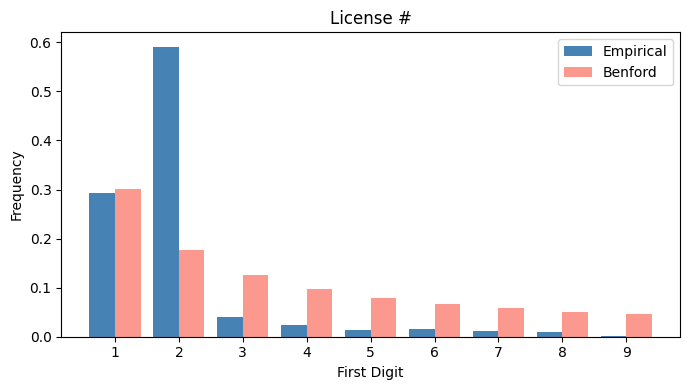

,digit,count,frequency,benford_expected
0,1,110630,0.4135,0.3010
1,2,125580,0.4694,0.1761
2,3,2532,0.0095,0.1249
3,4,5080,0.0190,0.0969
4,5,13695,0.0512,0.0792
5,6,7989,0.0299,0.0669
6,7,724,0.0027,0.0580
7,8,739,0.0028,0.0512
8,9,562,0.0021,0.0458


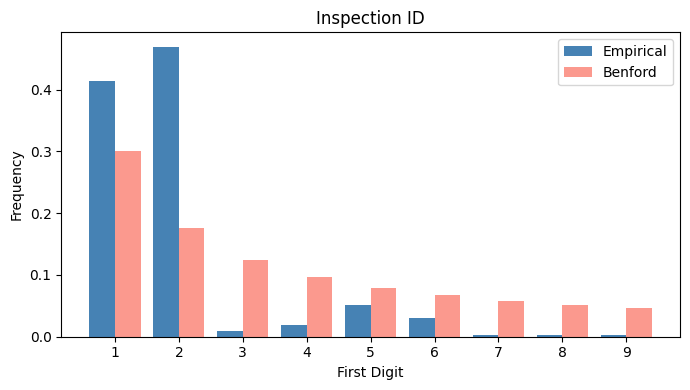

,Inspection ID,DBA Name,AKA Name,License #,Facility Type,Risk,Address,City,State,Zip,Inspection Date,Inspection Type,Results,Violations,Latitude,Longitude,Location,inspection_date_parsed,No. of Violations
0,2589375,PERFECT BEGINNINGS CHILD DEVELOPMENT CENTER,PERFECT BEGINNINGS CHILD DEVELOPMENT CENTER,2385784.0,Daycare Above and Under 2 Years,Risk 1 (High),1500 W 119TH ST,CHICAGO,IL,60643,02/08/2024,License,Pass,"51. PLUMBING INSTALLED; PROPER BACKFLOW DEVICES - Comments: OBSERVED MISSING DRAIN STOPPERS FOR THE 3-COMPARTMENT SINK. INSTRUCTED TO PROVIDE DRAIN STOPPERS FOR ALL THREE BASINS OF 3-COMPARTMENT SINK AND MAINTAIN. | 55. PHYSICAL FACILITIES INSTALLED, MAINTAINED & CLEAN - Comments: OBSERVED SMALL GREASE SPILL BENEATH 3-COMPARTMENT SINK IN CORNER. INSTRUCTED TO CLEAN AND SANITIZE AND ARRANGE AREA TO ALLOW FOR FREQUENT CLEANING AND MAINTAIN. | 55. PHYSICAL FACILITIES INSTALLED, MAINTAINED & CLEAN - Comments: OBSERVED BASE COVING MISSING ON EXTERIOR WALL IN KITCHEN AREA. INSTRUCTED TO PROVIDE BASE COVING FOR ALL WALLS IN AREAS SUBJECT TO SPLASHING AND/OR MOISTURE AND MAINTAIN. | 56. ADEQUATE VENTILATION & LIGHTING; DESIGNATED AREAS USED - Comments: OBSERVED VENTILATION HOOD FILTER HEAVILY SOILED WITH CAKED GREASE. INSTRUCTED TO CLEAN OR REPLACE FILTER AND MAINTAIN.",41.677685,-87.659020,"(41.677685065833224, -87.65901954921286)",2024-02-08,4
1,2589377,BIG BOSS SPICY FRIED CHICKEN,BIG BOSS SPICY FRIED CHICKEN,2807954.0,Restaurant,Risk 1 (High),2520 S HALSTED ST,CHICAGO,IL,60608,02/08/2024,Canvass,Fail,"23. PROPER DATE MARKING AND DISPOSITION - Comments: 3-501.17 OBSERVED READY-TO-EAT TCS FOODS (MACARONI SALAD) IN A REFRIGERATOR WITHOUT LABELS CONTAINING THE PRODUCT DISCARD DATE. INSTRUCTED TO PROVIDE LABELS WITH PRODUCT DISCARD DATES FOR ALL TCS RTE FOODS THAT ARE HELD FOR MORE THAN 24 HOURS IN A REFRIGERATOR. PRIORITY FOUNDATION. CITATION ISSUED 7-38-005. | 37. FOOD PROPERLY LABELED; ORIGINAL CONTAINER - Comments: 3-302.12 OBSERVED SPICES/DRY STORAGE (RICE) OUT OF THE ORIGINAL PACKAGING IN CONTAINERS WITHOUT LABELS. INSTRUCTED TO LABEL ALL SPICE/DRY STORAGE CONTAINERS. | 38. INSECTS, RODENTS, & ANIMALS NOT PRESENT - Comments: 6-501.111 OBSERVED EVIDENCE OF RODENT ACTIVITY ON SITE. OBSERVED ABOUT 200 RODENT DROPPINGS LOCATED BEHIND THE COOKING EQUIPMENT AND UNDER ALL DRY STORAGE SHELVES. OBSERVED ABOUT 150 RODENT DROPPINGS IN THE HOT WATER HEATER ROOM, BEHIND REACH IN FREEZERS, AND REFRIGERATION UNITS. OBSERVED ABOUT 100 RODENT DROPPINGS INSIDE OF ALL FRYERS. INSTRUCTED TO ELIMINATE RODENT ACTIVITY, CLEAN AND SANITIZE AFFECTED AREAS AND RECOMMENDED CONTACTING PEST CONTROL FOR A SERVICE. PRIORITY FOUNDATION. CITATION ISSUED 7-38-020(A). | 38. INSECTS, RODENTS, & ANIMALS NOT PRESENT - Comments: 6-202.15 OBSERVED FRONT ENTRANCE DOOR WITH A 1/4 INCH GAP AT THE BOTTOM. INSTRUCTED TO MAKE SAID FRONT ENTRANCE DOOR RODENT PROOFED AND TIGHT FITTING. | 45. SINGLE-USE/SINGLE-SERVICE ARTICLES: PROPERLY STORED & USED - Comments: 4-502.13 OBSERVED SINGLE-USE CONTAINERS (SOY SAUCE CONTAINERS) AND SINGLE-USE GROCERY BAGS BEING USED FOR FOOD STORAGE IN THE REACH-IN FREEZERS AND THE WALK-IN COOLER. INSTRUCTED TO ONLY USE FOOD-GRADE STORAGE CONTAINERS AND FOOD-GRADE STORAGE BAGS FOR ALL FOOD STORAGE. | 49. NON-FOOD/FOOD CONTACT SURFACES CLEAN - Comments: 4-601.11(C) OBSERVED ALL NON-FOOD CONTACT SURFACES WITH EXCESSIVE ACCUMULATED FOOD DEBRIS LOCATED ON THE HANDLES OF ALL REFRIGERATION UNITS AND PREP COOLERS, INTERIOR OF ALL REFRIGERATION UNITS AND PREP COOLERS, CUTTING BOARDS WITH DARK GROOVES USED FOR SALAD PREPARATION, INTERIOR OF ALL FRYERS WITH EXCESSIVE ACCUMULATED FOOD AND GREASE DEBRIS. INSTRUCTED TO CLEAN AND SANITIZE ALL. | 53. TOILET FACILITIES: PROPERLY CONSTRUCTED, SUPPLIED, & CLEANED - Comments: 5-501.17 OBSERVED NO COVERED RECEPTACLES INSIDE REAR EMPLOYEE'S TOILET ROOMS. INSTRUCTED TO PROVIDE. | 54. GARBAGE & REFUSE PROPERLY DISPOSED; FACILITIES MAINTAINED - Comments: 5-501.113 OBSERVED FACILITY USING SINGLE-USE FOOD STORAGE C

In [7]:
run_single_column_profiling("Food_Inspections_20240215.csv")

In [22]:
"""
Another way to run association rule mining:

cols_to_mine = ['Facility Type', 'Risk', 'Results']
run_association_rule_mining(
    csv_path="Food_Inspections_20240215.csv",
    columns_to_analyze=cols_to_mine,
    min_support=0.03,
)
"""

run_association_rule_mining("Food_Inspections_20240215.csv")


TASK: ASSOCIATION RULE MINING
------ 1. LOAD DATA ------



------ 2. SELECTING RELEVANT CATEGORICAL COLUMNS ------



------ 3. ONE-HOT ENCODING THE DATA ------



------ 4. RUNNING APRIORI ALGORITHM (min_support=0.05) ------



------ 5. GENERATE ASSOCIATION RULES ------

Successfully generated 32 rules.

------ Top 10 Association Rules ------


,antecedents,consequents,support,confidence,lift
0,(Inspection Type_Canvass),(Results_Out of Business),0.069281,0.134927,1.914369
1,(Results_Out of Business),(Inspection Type_Canvass),0.069281,0.982967,1.914369
2,"(Facility Type_Restaurant, Inspection Type_Canvass Re-Inspection)","(Risk_Risk 1 (High), Results_Pass)",0.052436,0.687503,1.743482
3,"(Risk_Risk 1 (High), Results_Pass)","(Facility Type_Restaurant, Inspection Type_Canvass Re-Inspection)",0.052436,0.132976,1.743482
4,(Inspection Type_Canvass Re-Inspection),"(Facility Type_Restaurant, Risk_Risk 1 (High), Results_Pass)",0.052436,0.467389,1.664103
5,"(Facility Type_Restaurant, Risk_Risk 1 (High), Results_Pass)",(Inspection Type_Canvass Re-Inspection),0.052436,0.186694,1.664103
6,"(Inspection Type_Canvass Re-Inspection, Risk_Risk 1 (High))","(Facility Type_Restaurant, Results_Pass)",0.052436,0.568483,1.632139
7,"(Facility Type_Restaurant, Results_Pass)","(Inspection Type_Canvass Re-Inspection, Risk_Risk 1 (High))",0.052436,0.150546,1.632139
8,(Inspection Type_Canvass Re-Inspection),"(Risk_Risk 1 (High), Results_Pass)",0.071838,0.640329,1.623850
9,"(Risk_Risk 1 (High), Results_Pass)",(Inspection Type_Canvass Re-Inspection),0.071838,0.182178,1.623850


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Inspection Type_Canvass),(Results_Out of Business),0.513468,0.070481,0.069281,0.134927,1.914369,1.0,0.033091,1.074498,0.981713,0.134612,0.069332,0.558947
1,(Results_Out of Business),(Inspection Type_Canvass),0.070481,0.513468,0.069281,0.982967,1.914369,1.0,0.033091,28.564823,0.513851,0.134612,0.964992,0.558947
2,"(Facility Type_Restaurant, Inspection Type_Canvass Re-Inspection)","(Risk_Risk 1 (High), Results_Pass)",0.076270,0.394328,0.052436,0.687503,1.743482,1.0,0.022361,1.938171,0.461645,0.125396,0.484050,0.410239
3,"(Risk_Risk 1 (High), Results_Pass)","(Facility Type_Restaurant, Inspection Type_Canvass Re-Inspection)",0.394328,0.076270,0.052436,0.132976,1.743482,1.0,0.022361,1.065402,0.704069,0.125396,0.061388,0.410239
4,(Inspection Type_Canvass Re-Inspection),"(Facility Type_Restaurant, Risk_Risk 1 (High), Results_Pass)",0.112189,0.280866,0.052436,0.467389,1.664103,1.0,0.020926,1.350206,0.449505,0.153943,0.259372,0.327042
5,"(Facility Type_Restaurant, Risk_Risk 1 (High), Results_Pass)",(Inspection Type_Canvass Re-Inspection),0.280866,0.112189,0.052436,0.186694,1.664103,1.0,0.020926,1.091608,0.554939,0.153943,0.083920,0.327042
6,"(Inspection Type_Canvass Re-Inspection, Risk_Risk 1 (High))","(Facility Type_Restaurant, Results_Pass)",0.092238,0.348306,0.052436,0.568483,1.632139,1.0,0.020309,1.510241,0.426662,0.135107,0.337854,0.359515
7,"(Facility Type_Restaurant, Results_Pass)","(Inspection Type_Canvass Re-Inspection, Risk_Risk 1 (High))",0.348306,0.092238,0.052436,0.150546,1.632139,1.0,0.020309,1.068641,0.594308,0.135107,0.064232,0.359515
8,(Inspection Type_Canvass Re-Inspection),"(Risk_Risk 1 (High), Results_Pass)",0.112189,0.394328,0.071838,0.640329,1.623850,1.0,0.027599,1.683961,0.432727,0.165267,0.406162,0.411254
9,"(Risk_Risk 1 (High), Results_Pass)",(Inspection Type_Canvass Re-Inspection),0.394328,0.112189,0.071838,0.182178,1.623850,1.0,0.027599,1.085580,0.634302,0.165267,0.078833,0.411254


In [25]:
run_functional_dependencies("Food_Inspections_20240215.csv")


TASK: FUNCTIONAL DEPENDENCIES
------ 1. LOAD DATA ------
  Full dataset : 259,025 rows, 15 columns
  Columns      : ['Inspection ID', 'DBA Name', 'AKA Name', 'License #', 'Facility Type', 'Risk', 'Address', 'City', 'State', 'Zip', 'Inspection Date', 'Inspection Type', 'Results', 'Latitude', 'Longitude']




------ 2. FIND FDs ------
  Sample size  : 150,000 rows

Unique value counts per column:
  Inspection ID                           : 150,000
  License #                               : 34,331
  DBA Name                                : 25,609
  AKA Name                                : 24,804
  Address                                 : 17,261
  Latitude                                : 16,408
  Longitude                               : 16,408
  Inspection Date                         : 3,533
  Facility Type                           : 434
  Inspection Type                         : 68
  Zip                                     : 64
  City                                    : 17
  Re

,lhs,rhs,lhs_size
0,[Inspection ID],DBA Name,1
1,[Inspection ID],AKA Name,1
2,[Inspection ID],License #,1
3,[Inspection ID],Facility Type,1
4,[Inspection ID],Risk,1
5,[Inspection ID],Address,1
6,[Inspection ID],City,1
7,[Inspection ID],State,1
8,[Inspection ID],Zip,1
9,[Inspection ID],Inspection Date,1


In [28]:
run_functional_dependencies_no_sampling("Food_Inspections_20240215.csv")


TASK: FUNCTIONAL DEPENDENCIES (NO SAMPLING)
------ 1. LOAD DATA ------
  Full dataset : 259,025 rows, 15 columns
  Columns      : ['Inspection ID', 'DBA Name', 'AKA Name', 'License #', 'Facility Type', 'Risk', 'Address', 'City', 'State', 'Zip', 'Inspection Date', 'Inspection Type', 'Results', 'Latitude', 'Longitude']




------ 2. FIND FDs ------
Unique value counts per column:
  Inspection ID                           : 259,025
  License #                               : 38,936
  DBA Name                                : 27,642
  AKA Name                                : 26,844
  Address                                 : 18,103
  Latitude                                : 17,128
  Longitude                               : 17,128
  Inspection Date                         : 3,559
  Facility Type                           : 483
  Inspection Type                         : 100
  Zip                                     : 64
  City                                    : 18
  Results           

,lhs,rhs,lhs_size
0,[Inspection ID],DBA Name,1
1,[Inspection ID],AKA Name,1
2,[Inspection ID],License #,1
3,[Inspection ID],Facility Type,1
4,[Inspection ID],Risk,1
5,[Inspection ID],Address,1
6,[Inspection ID],City,1
7,[Inspection ID],State,1
8,[Inspection ID],Zip,1
9,[Inspection ID],Inspection Date,1


# Handle Data Quality Problem

Uses the actual outputs from the three analysis tasks above:
- **`arm_rules`** from `run_association_rule_mining()`
- **`fds_df`** from `run_functional_dependencies()` or `run_functional_dependencies_no_sampling()`

Three quality checks are chained in order:
1. **ARM anomaly detection** — flag rows with unexpected attribute combinations
2. **FD violation repair** — detect & fix inconsistencies using majority-vote


--> this i havent do because i dont see any file in github 3. **IND checks** — enforce valid value sets and cross-column inclusion rules

## Helpers

In [29]:
import ast as _ast

def _load(csv_path):
    df = pd.read_csv(csv_path, encoding="utf-8", dtype=str)
    df.columns = [c.strip() for c in df.columns]
    for col in df.columns:
        df[col] = df[col].str.strip()
    return df

def _parse_lhs(lhs_val):
    """Handle lhs stored as a Python list OR its string repr."""
    if isinstance(lhs_val, list):
        return lhs_val
    try:
        return _ast.literal_eval(str(lhs_val))
    except Exception:
        return [str(lhs_val)]

## Step 1 — ARM-Based Anomaly Detection

For each strong rule **A → B** (confidence ≥ threshold, lift ≥ threshold),
a row is **anomalous** if it satisfies antecedent A but **not** consequent B.

Based on the actual rules mined from `Food_Inspections_20240215.csv`, the strongest rule is `{Results_Out of Business} → {Inspection Type_Canvass}` with confidence = 0.983, lift = 1.91. A record where the result is 'Out of Business' but the inspection type is NOT 'Canvass' is suspicious.

In [30]:
def arm_anomaly_detection(
    df,
    rules,
    columns_to_analyze=None,
    confidence_threshold=0.80,
    lift_threshold=1.5,
):
    """
    Flag rows that violate strong association rules.

    Parameters
    ----------
    df                   : original DataFrame
    rules                : output of run_association_rule_mining()
    columns_to_analyze   : columns used when the rules were mined
                           default: ['Facility Type','Risk','Inspection Type','Results']
    confidence_threshold : minimum rule confidence  (default 0.80)
    lift_threshold       : minimum rule lift        (default 1.5)

    Returns
    -------
    df_flagged  : df + arm_anomaly_flag, arm_violated_rules columns
    arm_summary : DataFrame — one row per violated rule with counts
    """
    print("\n" + "=" * 60)
    print("STEP 1 — ARM-BASED ANOMALY DETECTION")
    print("=" * 60)

    if columns_to_analyze is None:
        columns_to_analyze = ["Facility Type", "Risk", "Inspection Type", "Results"]

    df_flagged = df.copy()
    df_flagged["arm_anomaly_flag"]   = False
    df_flagged["arm_violated_rules"] = ""

    # Filter for strong rules only
    strong = rules[
        (rules["confidence"] >= confidence_threshold) &
        (rules["lift"]       >= lift_threshold)
    ].copy()
    print(f"  Strong rules (conf>={confidence_threshold}, lift>={lift_threshold}): {len(strong)} / {len(rules)}")

    if strong.empty:
        print("  No strong rules found — try lowering the thresholds.")
        return df_flagged, pd.DataFrame()

    # One-hot encode once — vectorised checks are far faster than row.apply()
    present = [c for c in columns_to_analyze if c in df.columns]
    df_enc  = pd.get_dummies(df[present].fillna("__MISSING__"), prefix=present).astype(bool)

    summary_rows = []
    for _, rule in strong.iterrows():
        ant_cols = [f for f in list(rule["antecedents"]) if f in df_enc.columns]
        con_cols = [f for f in list(rule["consequents"]) if f in df_enc.columns]
        if not ant_cols or not con_cols:
            continue

        # violated = antecedent satisfied AND consequent NOT satisfied
        violated = df_enc[ant_cols].all(axis=1) & ~df_enc[con_cols].all(axis=1)
        n = violated.sum()

        rule_str = (
            f"{set(rule['antecedents'])} -> {set(rule['consequents'])} "
            f"[conf={rule['confidence']:.2f}, lift={rule['lift']:.2f}]"
        )
        if n > 0:
            df_flagged.loc[violated, "arm_anomaly_flag"] = True
            df_flagged.loc[violated, "arm_violated_rules"] += (
                df_flagged.loc[violated, "arm_violated_rules"]
                .apply(lambda x: ("" if x == "" else " | ") + rule_str)
            )
            print(f"\n  Rule  : {rule_str}")
            print(f"  Rows  : {n:,}  ({n/len(df)*100:.2f}%)")

        summary_rows.append({
            "rule"        : rule_str,
            "confidence"  : round(rule["confidence"], 4),
            "lift"        : round(rule["lift"],       4),
            "n_violations": n,
            "pct"         : round(n / len(df) * 100, 2),
        })

    arm_summary = pd.DataFrame(summary_rows)
    total = df_flagged["arm_anomaly_flag"].sum()
    print(f"\n  -> Total ARM anomalies flagged: {total:,}  ({total/len(df)*100:.2f}%)")
    return df_flagged, arm_summary

## Step 2 — FD-Based Violation Repair

From the actual FD discovery output, the confirmed FDs are:
- `[Inspection ID]` → every column (primary key, no violations)
- `[Address]` → `Latitude`, `Longitude` (an address should have one set of coords)
- `[Latitude]` ↔ `[Longitude]` (bidirectional)
- Everything → `State` (trivially holds — only value is 'IL')
- Several composite-LHS FDs involving `City` and `Zip`

**Bug fixed:** the original `majority_vote` branch used `.map()` without `.fillna()`,
which would set rows with NaN LHS values to NaN in the RHS column — wiping valid data.
This is now corrected with `.fillna(df_fixed[rhs])`.

In [31]:
def fd_violation_repair(df, fds_df, strategy="majority_vote"):
    """
    Detect and repair Functional Dependency violations.

    A violation of  LHS -> RHS  is any row whose LHS value maps to more than
    one distinct RHS value across the dataset.

    Parameters
    ----------
    df       : original DataFrame
    fds_df   : output of run_functional_dependencies() — columns: lhs, rhs, lhs_size
    strategy : 'majority_vote'  replace minority RHS with most-frequent value per LHS group
               'flag_only'     mark violations without changing any values

    Returns
    -------
    df_fixed  : repaired DataFrame + fd_violation_flag, fd_fixed_columns
    fd_report : DataFrame — one row per (FD, LHS-group) violation
    """
    print("\n" + "=" * 60)
    print("STEP 2 — FD-BASED VIOLATION REPAIR")
    print("=" * 60)

    df_fixed = df.copy()
    df_fixed["fd_violation_flag"] = False
    df_fixed["fd_fixed_columns"]  = ""
    report_rows = []

    for _, fd_row in fds_df.iterrows():
        lhs = _parse_lhs(fd_row["lhs"])
        rhs = str(fd_row["rhs"])

        missing = [c for c in lhs + [rhs] if c not in df_fixed.columns]
        if missing:
            continue

        lhs_str = " + ".join(lhs)

        # Rows where the same LHS maps to > 1 distinct RHS value
        group_nunique = df_fixed.groupby(lhs)[rhs].transform("nunique")
        violated = group_nunique > 1
        n_viol = violated.sum()
        if n_viol == 0:
            continue

        n_groups = df_fixed.loc[violated].groupby(lhs).ngroups
        print(f"\n  FD   : [{lhs_str}] -> '{rhs}'")
        print(f"  Rows : {n_viol:,}  in  {n_groups:,} LHS group(s)")

        df_fixed.loc[violated, "fd_violation_flag"] = True
        df_fixed.loc[violated, "fd_fixed_columns"] += (
            df_fixed.loc[violated, "fd_fixed_columns"]
            .apply(lambda x: ("" if x == "" else ", ") + f"{lhs_str}->{rhs}")
        )

        # Majority RHS value per LHS group (computed on non-null rows)
        majority_map = (
            df_fixed.dropna(subset=lhs + [rhs])
            .groupby(lhs)[rhs]
            .agg(lambda x: x.value_counts().idxmax())
        )

        # Collect report rows BEFORE repair
        for lhs_key, grp in df_fixed.loc[violated].groupby(lhs):
            maj = majority_map.get(lhs_key, None)
            report_rows.append({
                "fd"               : f"[{lhs_str}] -> '{rhs}'",
                "lhs_value"        : str(lhs_key),
                "rhs_values_found" : str(grp[rhs].value_counts().to_dict()),
                "majority_value"   : str(maj),
                "rows_affected"    : len(grp),
                "strategy"         : strategy,
            })

        # Repair
        if strategy == "majority_vote":
            old_vals = df_fixed[rhs].copy()
            if len(lhs) == 1:
                # BUG FIX: add .fillna(old_vals) so NaN-LHS rows keep their original value
                df_fixed[rhs] = df_fixed[lhs[0]].map(majority_map).fillna(old_vals)
            else:
                def _get_majority(row):
                    key = tuple(row[c] for c in lhs)
                    return majority_map.get(key, row[rhs])
                df_fixed[rhs] = df_fixed.apply(_get_majority, axis=1)
            n_changed = (old_vals != df_fixed[rhs]).sum()
            print(f"  Fixed : {n_changed:,} values updated in '{rhs}'")

    fd_report = pd.DataFrame(report_rows)
    total = df_fixed["fd_violation_flag"].sum()
    print(f"\n  -> Total FD violations flagged: {total:,}  ({total/len(df)*100:.2f}%)")
    if not fd_report.empty:
        print("\n  FD Violation Report (top 20):")
        display(fd_report.head(20))
    return df_fixed, fd_report

## Combined Pipeline

Pass in the already-computed `arm_rules` and `fds_df` to avoid re-running the mining steps.

In [32]:
def run_data_quality_pipeline_no_ind(
    csv_path,
    arm_rules=None,
    fds_df=None,
    arm_conf_threshold=0.80,
    arm_lift_threshold=1.5,
    fd_strategy="majority_vote",
    output_path="Food_Inspections_cleaned.csv",
):
    """
    Data quality pipeline focusing on ARM anomaly detection and FD repair.
    (Inclusion Dependency checks removed).
    """
    print("\n" + "=" * 60)
    print("DATA QUALITY PIPELINE (ARM + FD ONLY)")
    print("=" * 60)

    # 1. LOAD DATA (Internal _load helper assumed)
    df = _load(csv_path)
    print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

    # STEP 1: ASSOCIATION RULE MINING (ARM)
    # Detects Statistical Anomalies (Lecture 11)
    if arm_rules is None:
        print("\n[Step 1] Running ARM from scratch...")
        from mlxtend.frequent_patterns import apriori, association_rules as _arm
        ARM_COLS = ["Facility Type", "Risk", "Inspection Type", "Results"]
        df_enc    = pd.get_dummies(df[ARM_COLS].dropna(), prefix=ARM_COLS).astype(bool)
        arm_rules = _arm(apriori(df_enc, min_support=0.05, use_colnames=True),
                         metric="lift", min_threshold=1.2)
        arm_rules = arm_rules.sort_values("lift", ascending=False).reset_index(drop=True)
        print(f"  {len(arm_rules)} rules generated.")
    else:
        print("\n[Step 1] Using provided ARM rules.")

    # Flag ARM Anomalies
    df_arm, arm_summary = arm_anomaly_detection(
        df, arm_rules,
        confidence_threshold=arm_conf_threshold,
        lift_threshold=arm_lift_threshold,
    )

    # STEP 2: FUNCTIONAL DEPENDENCIES (FD)
    # Corrects Consistency Errors (Lecture 12)
    if fds_df is None:
        print("\n[Step 2] No FD results provided — skipping FD repair.")
        df_fd = df.copy()
        df_fd["fd_violation_flag"] = False
        df_fd["fd_fixed_columns"]  = ""
        fd_report = pd.DataFrame()
    else:
        print("\n[Step 2] Using provided FD results.")
        df_fd, fd_report = fd_violation_repair(df.copy(), fds_df, strategy=fd_strategy)

    # STEP 3: MERGE FLAGS (IND Step Removed)
    print("\n[Step 3] Merging ARM and FD results...")
    # We use df_fd as our base because it contains the repaired values
    df_clean = df_fd.copy()

    # Import ARM flags from Step 1
    df_clean["arm_anomaly_flag"]   = df_arm["arm_anomaly_flag"].values
    df_clean["arm_violated_rules"] = df_arm["arm_violated_rules"].values

    # Logic for "Any Issue" only considers ARM and FD now
    df_clean["any_quality_issue"]  = (
        df_clean["arm_anomaly_flag"] |
        df_clean["fd_violation_flag"]
    )

    # 2. FINAL SUMMARY
    n     = len(df_clean)
    arm_n = int(df_clean["arm_anomaly_flag"].sum())
    fd_n  = int(df_clean["fd_violation_flag"].sum())
    any_n = int(df_clean["any_quality_issue"].sum())

    print("\n" + "=" * 60)
    print("QUALITY PIPELINE SUMMARY")
    print("=" * 60)
    print(f"  Total rows                     : {n:,}")
    print(f"  ARM anomalies flagged          : {arm_n:,}  ({arm_n/n*100:.2f}%)")
    print(f"  FD violations flagged/fixed    : {fd_n:,}  ({fd_n/n*100:.2f}%)")
    print(f"  Any quality issue (ARM or FD)  : {any_n:,}  ({any_n/n*100:.2f}%)")

    df_clean.to_csv(output_path, index=False)
    print(f"\n  Saved -> {output_path}")

    return df_clean, {
        "arm_summary": arm_summary,
        "fd_report"  : fd_report,
        "row_counts" : {
            "total": n,
            "arm_anomalies": arm_n,
            "fd_violations": fd_n,
            "any_issue": any_n
        },
    }

## Run

Pass the already-computed results from earlier cells into the pipeline
to avoid re-running ARM and FD discovery.

- `arm_rules` is the return value of `run_association_rule_mining()`
- `fds_df` is the return value of `run_functional_dependencies()`

In [33]:
CSV_PATH = "Food_Inspections_20240215.csv"

# ── Option A: reuse already-computed results (recommended — avoids recomputation) ──
# arm_rules and fds_df must be in scope from running the cells above
# df_clean, report = run_data_quality_pipeline(
#     CSV_PATH,
#     arm_rules          = arm_rules,   # from run_association_rule_mining()
#     fds_df             = fds_df,      # from run_functional_dependencies()
#     arm_conf_threshold = 0.80,
#     arm_lift_threshold = 1.5,
#     fd_strategy        = "majority_vote",
# )

# ── Option B: compute everything from scratch ─────────────────────────────────────
df_clean, report = run_data_quality_pipeline_no_ind(CSV_PATH)


DATA QUALITY PIPELINE (ARM + FD ONLY)
Loaded: 267,531 rows x 17 columns

[Step 1] Running ARM from scratch...
  32 rules generated.

STEP 1 — ARM-BASED ANOMALY DETECTION
  Strong rules (conf>=0.8, lift>=1.5): 1 / 32

  Rule  : {'Results_Out of Business'} -> {'Inspection Type_Canvass'} [conf=0.98, lift=1.91]
  Rows  : 360  (0.13%)

  -> Total ARM anomalies flagged: 360  (0.13%)

[Step 2] No FD results provided — skipping FD repair.

[Step 3] Merging ARM and FD results...

QUALITY PIPELINE SUMMARY
  Total rows                     : 267,531
  ARM anomalies flagged          : 360  (0.13%)
  FD violations flagged/fixed    : 0  (0.00%)
  Any quality issue (ARM or FD)  : 360  (0.13%)

  Saved -> Food_Inspections_cleaned.csv


## Inspect Results

In [34]:
# ARM anomaly samples
arm_flagged = df_clean[df_clean["arm_anomaly_flag"]]
print(f"ARM anomalies: {len(arm_flagged):,} rows")
display(arm_flagged[["DBA Name","Facility Type","Risk","Inspection Type",
                      "Results","arm_violated_rules"]].head(5))

ARM anomalies: 360 rows


,DBA Name,Facility Type,Risk,Inspection Type,Results,arm_violated_rules
503,TORTAS FUTBOLERAS,Restaurant,Risk 1 (High),License,Out of Business,"{'Results_Out of Business'} -> {'Inspection Type_Canvass'} [conf=0.98, lift=1.91]"
1893,MOON LIGHT MARKET,Grocery Store,Risk 3 (Low),Non-Inspection,Out of Business,"{'Results_Out of Business'} -> {'Inspection Type_Canvass'} [conf=0.98, lift=1.91]"
2002,SOUTH LOOP CLUB INC,Restaurant,Risk 1 (High),Non-Inspection,Out of Business,"{'Results_Out of Business'} -> {'Inspection Type_Canvass'} [conf=0.98, lift=1.91]"
2133,CHECKERS/ RALLY'S,Restaurant,Risk 1 (High),Canvass Re-Inspection,Out of Business,"{'Results_Out of Business'} -> {'Inspection Type_Canvass'} [conf=0.98, lift=1.91]"
2174,"D TRAIN FOOD MART, INC",Restaurant,Risk 2 (Medium),Complaint,Out of Business,"{'Results_Out of Business'} -> {'Inspection Type_Canvass'} [conf=0.98, lift=1.91]"


In [35]:
# FD violation samples
fd_flagged = df_clean[df_clean["fd_violation_flag"]]
print(f"FD violations: {len(fd_flagged):,} rows")
display(fd_flagged[["DBA Name","Address","City","State","Zip",
                     "Latitude","Longitude","fd_fixed_columns"]].head(5))

FD violations: 0 rows


,DBA Name,Address,City,State,Zip,Latitude,Longitude,fd_fixed_columns


In [36]:
# Overall summary
display(pd.DataFrame([report["row_counts"]]))

print("\nARM rule violation summary:")
display(report["arm_summary"])

if not report["fd_report"].empty:
    print("\nFD violation report:")
    display(report["fd_report"])

,total,arm_anomalies,fd_violations,any_issue
0,267531,360,0,360



ARM rule violation summary:


,rule,confidence,lift,n_violations,pct
0,"{'Results_Out of Business'} -> {'Inspection Type_Canvass'} [conf=0.98, lift=1.91]",0.983,1.9144,360,0.13
